# 02 — Handover Analysis
Extract cell-to-cell handovers, build the route graph, identify most-used paths.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan')
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pipeline.ingest import load_raw, clean
from pipeline.handovers import extract_handovers, build_graph

df = clean(load_raw())
handovers = extract_handovers(df)
handovers.head(10)

2026-03-15 20:18:39.166 | INFO     | pipeline.ingest:load_raw:17 - Loading raw data from /home/jovyan/telco-poc/data/SRFG-v1.csv
2026-03-15 20:21:07.086 | INFO     | pipeline.ingest:load_raw:19 - Loaded 267,198 rows
2026-03-15 20:21:07.087 | INFO     | pipeline.ingest:clean:24 - Cleaning data...
2026-03-15 20:21:07.153 | INFO     | pipeline.ingest:clean:42 - Clean data: 264,254 rows, 498 trips
2026-03-15 20:21:07.153 | INFO     | pipeline.handovers:extract_handovers:17 - Extracting handover events...
2026-03-15 20:21:07.223 | INFO     | pipeline.handovers:extract_handovers:37 - Found 9,294 handover events across 498 trips


,trip,time,from_cell,to_cell,from_lat,from_long,lat,long,rsrp,sinr,signal
0,2018-01-15-1736,2018-01-15 16:44:18,798470,710664,47.850742,13.088385,47.850803,13.088757,-82.0,7.0,3.0
1,2018-01-15-1736,2018-01-15 16:44:55,710664,710663,47.851692,13.102032,47.851753,13.102407,-70.0,3.0,1.0
2,2018-01-15-1736,2018-01-15 16:44:59,710663,710662,47.851944,13.103567,47.852010,13.103967,-82.0,8.0,1.0
3,2018-01-15-1736,2018-01-15 16:45:31,710662,706824,47.854385,13.117515,47.854485,13.117980,-88.0,6.0,3.0
4,2018-01-15-1736,2018-01-15 16:45:49,706824,706822,47.855890,13.125334,47.855940,13.125705,-71.0,-4.0,4.0
5,2018-01-15-1736,2018-01-15 16:45:50,706822,706823,47.855940,13.125705,47.855984,13.126077,-68.0,11.0,3.0
6,2018-01-15-1736,2018-01-15 16:46:18,706823,1323015,47.856026,13.136869,47.855995,13.137259,-94.0,7.0,2.0
7,2018-01-15-1736,2018-01-15 16:48:13,1323015,706056,47.851635,13.189816,47.851807,13.190211,-105.0,0.0,2.0
8,2018-01-15-1736,2018-01-15 16:48:39,706056,758792,47.855583,13.199387,47.855663,13.199797,-102.0,-3.0,3.0
9,2018-01-15-1736,2018-01-15 16:48:41,758792,706056,47.855732,13.200212,47.855793,13.200630,-109.0,-4.0,1.0


In [2]:
G = build_graph(handovers)
print(f'Nodes (cells): {G.number_of_nodes()}')
print(f'Edges (handover pairs): {G.number_of_edges()}')
print()

# Top 10 most used handover routes
print('Top 10 most used handover routes:')
edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:10]
for src, dst, data in edges:
    print(f'  Cell {src} → Cell {dst}  |  count: {data["weight"]}  |  avg RSRP: {data["avg_rsrp"]} dBm')

2026-03-15 20:21:07.249 | INFO     | pipeline.handovers:build_graph:61 - Graph: 88 cells, 318 handover edges


Nodes (cells): 88
Edges (handover pairs): 318

Top 10 most used handover routes:
  Cell 706056 → Cell 1577478  |  count: 267.0  |  avg RSRP: -98.8 dBm
  Cell 754184 → Cell 758790  |  count: 212.0  |  avg RSRP: -77.7 dBm
  Cell 754182 → Cell 754184  |  count: 209.0  |  avg RSRP: -74.5 dBm
  Cell 421638 → Cell 0  |  count: 208.0  |  avg RSRP: -114.2 dBm
  Cell 758790 → Cell 758792  |  count: 207.0  |  avg RSRP: -88.2 dBm
  Cell 706824 → Cell 710662  |  count: 204.0  |  avg RSRP: -81.1 dBm
  Cell 421638 → Cell 754182  |  count: 201.0  |  avg RSRP: -93.5 dBm
  Cell 1577478 → Cell 706056  |  count: 201.0  |  avg RSRP: -101.5 dBm
  Cell 710664 → Cell 798470  |  count: 200.0  |  avg RSRP: -81.6 dBm
  Cell 710662 → Cell 710663  |  count: 197.0  |  avg RSRP: -66.5 dBm


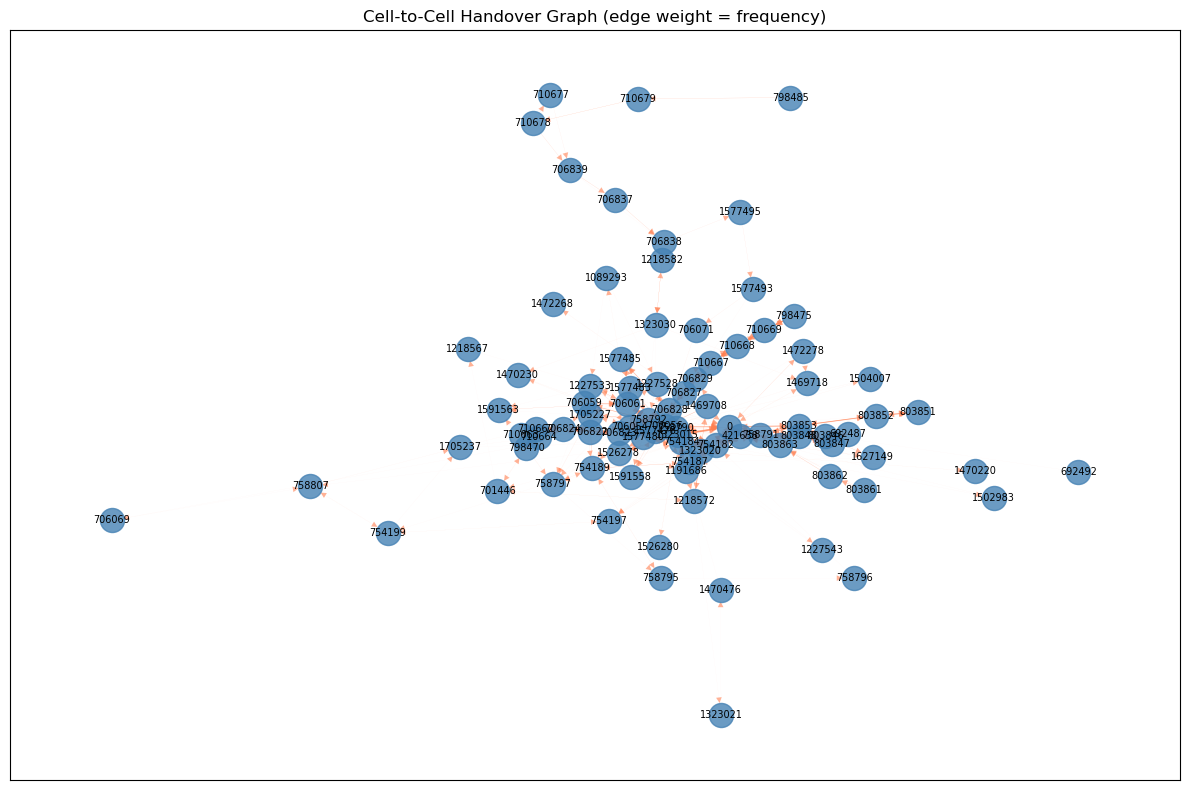

In [3]:
# Visualise the graph
fig, ax = plt.subplots(figsize=(12, 8))
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(weights)
norm_weights = [3 * w / max_w for w in weights]

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='steelblue', alpha=0.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G, pos, width=norm_weights, alpha=0.6, 
                        edge_color='coral', arrows=True, ax=ax)
ax.set_title('Cell-to-Cell Handover Graph (edge weight = frequency)')
plt.tight_layout()